# P9 - Lapage : Analyse du CA - Effet temporel

---

### Objectifs de cette session

1. **Analyser** l'évolution du chiffre d'affaires avec les moyennes mobiles

---

## 1. Configuration de l'environnement

In [5]:
# Import des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration de l'affichage
pd.set_option('display.max_columns', None)  # Afficher toutes les colonnes
pd.set_option('display.max_rows', 100)      # Limiter à 100 lignes
pd.set_option('display.width', None)        # Pas de limite de largeur

# Style des graphiques
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("✅ Bibliothèques chargées avec succès !")

✅ Bibliothèques chargées avec succès !


---

## 2. Chargement des données

Nous avons 1 fichier CSV à charger :
- `transactions_enrichies.csv` : données de transactions enrichies des clients et produits, fichier préparé à l'issue de l'inspection des données.

In [11]:
# Définir le chemin vers les données
# À adapter selon votre structure de projet
DATA_PATH = "../data/"

# Chargement des 3 fichiers
transactions_enrichies = pd.read_csv(DATA_PATH + "processed/transactions_enrichies.csv")

print("✅ Fichiers chargés avec succès !")
print(f"   - customers    : {len(transactions_enrichies):,} lignes")


transactions_enrichies.info()

✅ Fichiers chargés avec succès !
   - customers    : 687,534 lignes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 687534 entries, 0 to 687533
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id_prod         687534 non-null  object 
 1   date            687534 non-null  object 
 2   session_id      687534 non-null  object 
 3   client_id       687534 non-null  object 
 4   price           687534 non-null  float64
 5   categ           687534 non-null  int64  
 6   sex             687534 non-null  object 
 7   birth           687534 non-null  int64  
 8   segment_client  687534 non-null  object 
 9   age_client      687534 non-null  int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 52.5+ MB


### 👀 Premier aperçu rapide

In [5]:
# Aperçu des premières lignes de chaque fichier
print("=" * 60)
print("CUSTOMERS - Premières lignes")
print("=" * 60)
display(transactions_enrichies.head(3))

CUSTOMERS - Premières lignes


,id_prod,date,session_id,client_id,price,categ,sex,birth,segment_client
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,11.99,0,f,1967,B2C
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,19.37,0,m,1960,B2C
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,4.50,0,m,1988,B2C


## 3. Préparation de la colonne date

In [6]:
# Convertir la colonne date en format datetime
print("Type actuel de 'date' :", transactions_enrichies['date'].dtype)
print("Exemple de valeur    :", transactions_enrichies['date'].iloc[0])

Type actuel de 'date' : object
Exemple de valeur    : 2021-03-01 00:01:07.843138


In [12]:
# Conversion en datetime
transactions_enrichies['date'] = pd.to_datetime(transactions_enrichies['date'])

print("✅ Conversion effectuée")
print("Nouveau type :", transactions_enrichies['date'].dtype)
print("\nPériode couverte :")
print(f"   - Du : {transactions_enrichies['date'].min()}")
print(f"   - Au : {transactions_enrichies['date'].max()}")

✅ Conversion effectuée
Nouveau type : datetime64[ns]

Période couverte :
   - Du : 2021-03-01 00:01:07.843138
   - Au : 2023-02-28 23:58:30.792755


In [13]:
transactions_enrichies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 687534 entries, 0 to 687533
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   id_prod         687534 non-null  object        
 1   date            687534 non-null  datetime64[ns]
 2   session_id      687534 non-null  object        
 3   client_id       687534 non-null  object        
 4   price           687534 non-null  float64       
 5   categ           687534 non-null  int64         
 6   sex             687534 non-null  object        
 7   birth           687534 non-null  int64         
 8   segment_client  687534 non-null  object        
 9   age_client      687534 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(5)
memory usage: 52.5+ MB


---

## 4. Analyse du Chiffre d'Affaires avec Moyennes Mobiles

### 🎯 Objectif
Visualiser l'évolution du CA et identifier les tendances grâce aux moyennes mobiles.

### 📚 Qu'est-ce qu'une moyenne mobile ?

Une **moyenne mobile** (ou rolling mean) lisse les variations quotidiennes pour faire ressortir la tendance.

- **Moyenne mobile 7 jours** : moyenne des 7 derniers jours → tendance hebdomadaire
- **Moyenne mobile 30 jours** : moyenne des 30 derniers jours → tendance mensuelle

```
Données brutes (très variables)    →    Moyenne mobile (tendance lissée)
    📈📉📈📉📈📉                              📈────────────
```

### 4.1 Calculer le CA journalier

In [8]:
# Calculer le CA par jour
# CA = somme des prix des produits vendus chaque jour

ca_journalier = transactions_enrichies.groupby(pd.Grouper(key='date', freq='D'))['price'].sum().reset_index()
ca_journalier.columns = ['date', 'ca']

print(f"✅ CA journalier calculé")
print(f"   - Nombre de jours : {len(ca_journalier)}")
print(f"   - CA moyen par jour : {ca_journalier['ca'].mean():.2f} €")
display(ca_journalier.head())

✅ CA journalier calculé
   - Nombre de jours : 730
   - CA moyen par jour : 16476.25 €


,date,ca
0,2021-03-01,16565.22
1,2021-03-02,15486.45
2,2021-03-03,15198.69
3,2021-03-04,15196.07
4,2021-03-05,17471.37


### 4.2 Calculer les moyennes mobiles

In [9]:
# Trier par date (indispensable pour les moyennes mobiles)
ca_journalier = ca_journalier.sort_values('date').reset_index(drop=True)

# Moyenne mobile 7 jours (1 semaine)
ca_journalier['mm_7j'] = ca_journalier['ca'].rolling(window=7).mean()

# Moyenne mobile 30 jours (1 mois)
ca_journalier['mm_30j'] = ca_journalier['ca'].rolling(window=30).mean()

print("✅ Moyennes mobiles calculées")
display(ca_journalier.head(10))

✅ Moyennes mobiles calculées


,date,ca,mm_7j,mm_30j
0,2021-03-01,16565.22,NaN,NaN
1,2021-03-02,15486.45,NaN,NaN
2,2021-03-03,15198.69,NaN,NaN
3,2021-03-04,15196.07,NaN,NaN
4,2021-03-05,17471.37,NaN,NaN
5,2021-03-06,15785.28,NaN,NaN
6,2021-03-07,14760.20,15780.468571,NaN
7,2021-03-08,15679.53,15653.941429,NaN
8,2021-03-09,15710.51,15685.950000,NaN
9,2021-03-10,15496.87,15728.547143,NaN


### 💡 Comprendre le code

```python
ca_journalier['ca'].rolling(window=7).mean()
```

| Partie | Explication |
|--------|-------------|
| `.rolling(window=7)` | Crée une "fenêtre glissante" de 7 valeurs |
| `.mean()` | Calcule la moyenne de cette fenêtre |

**Note** : Les premières valeurs sont `NaN` car il n'y a pas assez de données pour calculer la moyenne (besoin de 7 jours pour la MM7).

### 4.3 Visualiser le CA avec les moyennes mobiles

### Version Matplotlib

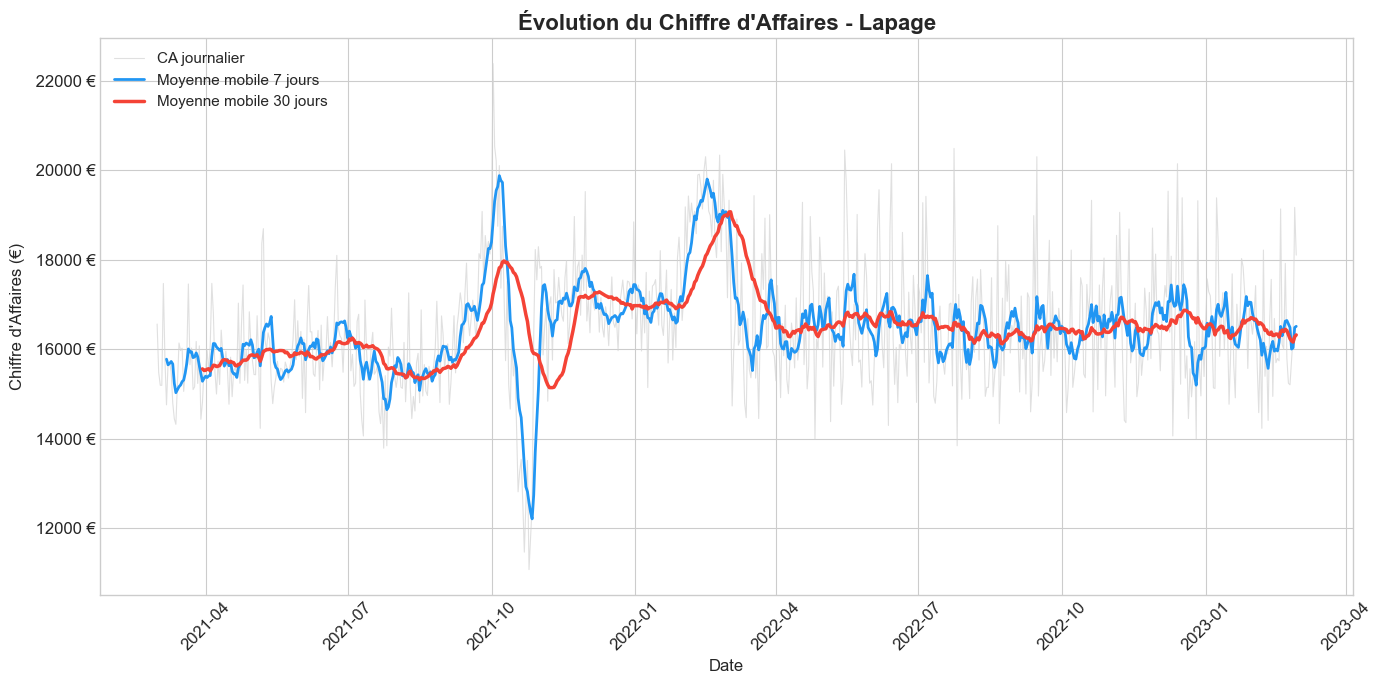

In [10]:
# Création du graphique
fig, ax = plt.subplots(figsize=(14, 7))

# CA journalier (points légers)
ax.plot(
    ca_journalier['date'], 
    ca_journalier['ca'], 
    color='lightgray', 
    linewidth=0.8,
    label='CA journalier',
    alpha=0.7
)

# Moyenne mobile 7 jours
ax.plot(
    ca_journalier['date'], 
    ca_journalier['mm_7j'], 
    color='#2196F3',  # Bleu
    linewidth=2,
    label='Moyenne mobile 7 jours'
)

# Moyenne mobile 30 jours
ax.plot(
    ca_journalier['date'], 
    ca_journalier['mm_30j'], 
    color='#F44336',  # Rouge
    linewidth=2.5,
    label='Moyenne mobile 30 jours'
)

# Mise en forme
ax.set_title('Évolution du Chiffre d\'Affaires - Lapage', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Chiffre d\'Affaires (€)', fontsize=12)
ax.legend(loc='upper left', fontsize=11)

# Formater l'axe Y avec séparateurs de milliers
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x: .0f} €'))

# Rotation des dates
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 📖 Comment lire ce graphique ?

| Élément | Ce qu'il montre |
|---------|----------------|
| **Ligne grise** | Variations quotidiennes ("bruit") |
| **Ligne bleue (MM7)** | Tendance hebdomadaire, réagit vite aux changements |
| **Ligne rouge (MM30)** | Tendance mensuelle, plus stable, montre la direction générale |

**Questions à se poser :**
- La tendance est-elle à la hausse ou à la baisse ?
- Y a-t-il des périodes de pics ou de creux ?
- Les variations hebdomadaires sont-elles importantes ?

### Version Plotly Express

In [11]:
import plotly.express as px

# Créer le graphique avec Plotly Express
fig = px.line(
    ca_journalier,
    x='date',
    y=['ca', 'mm_7j', 'mm_30j'],
    title="Évolution du Chiffre d'Affaires - Lapage",
    labels={
        'date': 'Date',
        'value': 'Chiffre d\'Affaires (€)',
        'variable': 'Indicateur'
    }
)

# Personnaliser les couleurs et styles
fig.update_traces(
    selector=dict(name='ca'),
    line=dict(color='lightgray', width=1),
    name='CA journalier'
)
fig.update_traces(
    selector=dict(name='mm_7j'),
    line=dict(color='#2196F3', width=2),
    name='Moyenne mobile 7 jours'
)
fig.update_traces(
    selector=dict(name='mm_30j'),
    line=dict(color='#F44336', width=3),
    name='Moyenne mobile 30 jours'
)

# Mise en forme
fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Chiffre d'Affaires (€)",
    legend_title="Indicateur",
    hovermode='x unified',
    template='plotly_white'
)

fig.show()

### Version Plotly Graph Objects

In [12]:
import plotly.graph_objects as go

fig = go.Figure()

# CA journalier (ligne légère en arrière-plan)
fig.add_trace(go.Scatter(
    x=ca_journalier['date'],
    y=ca_journalier['ca'],
    mode='lines',
    name='CA journalier',
    line=dict(color='lightgray', width=1),
    hovertemplate='%{x}<br>CA: %{y:,.0f} €<extra></extra>'
))

# Moyenne mobile 7 jours
fig.add_trace(go.Scatter(
    x=ca_journalier['date'],
    y=ca_journalier['mm_7j'],
    mode='lines',
    name='Moyenne mobile 7 jours',
    line=dict(color='#2196F3', width=2),
    hovertemplate='%{x}<br>MM7: %{y:,.0f} €<extra></extra>'
))

# Moyenne mobile 30 jours
fig.add_trace(go.Scatter(
    x=ca_journalier['date'],
    y=ca_journalier['mm_30j'],
    mode='lines',
    name='Moyenne mobile 30 jours',
    line=dict(color='#F44336', width=3),
    hovertemplate='%{x}<br>MM30: %{y:,.0f} €<extra></extra>'
))

# Mise en forme
fig.update_layout(
    title=dict(
        text="Évolution du Chiffre d'Affaires - Lapage",
        font=dict(size=18)
    ),
    xaxis_title="Date",
    yaxis_title="Chiffre d'Affaires (€)",
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5
    ),
    hovermode='x unified',
    template='plotly_white',
    height=500
)

# Formater l'axe Y avec séparateurs de milliers
fig.update_yaxes(tickformat=",")

fig.show()

### 4.4 Evolution du CA par segment client

In [15]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

# Calculer le CA journalier par segment
def calculer_ca_avec_mm(df_segment):
    """Calcule le CA journalier et les moyennes mobiles pour un segment."""
    ca = df_segment.groupby(pd.Grouper(key='date', freq='D'))['price'].sum().reset_index()
    ca.columns = ['date', 'ca']
    ca = ca.sort_values('date').reset_index(drop=True)
    ca['mm_7j'] = ca['ca'].rolling(window=7).mean()
    ca['mm_30j'] = ca['ca'].rolling(window=30).mean()
    return ca

# Séparer par segment
ca_b2b = calculer_ca_avec_mm(transactions_enrichies[transactions_enrichies['segment_client'] == 'B2B'])
ca_b2c = calculer_ca_avec_mm(transactions_enrichies[transactions_enrichies['segment_client'] == 'B2C'])

# Créer les subplots (2 lignes, 1 colonne)
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,           # Partager l'axe X
    vertical_spacing=0.08,       # Espacement entre les graphiques
    subplot_titles=("🏢 Segment B2B", "🛒 Segment B2C")
)

# === GRAPHIQUE B2B (row=1) ===
# CA journalier
fig.add_trace(go.Scatter(
    x=ca_b2b['date'],
    y=ca_b2b['ca'],
    mode='lines',
    name='CA journalier',
    line=dict(color='lightgray', width=1),
    hovertemplate='%{x}<br>CA: %{y:,.0f} €<extra></extra>',
    legendgroup='ca',
    showlegend=True
), row=1, col=1)

# MM 7 jours
fig.add_trace(go.Scatter(
    x=ca_b2b['date'],
    y=ca_b2b['mm_7j'],
    mode='lines',
    name='MM 7 jours',
    line=dict(color='#2196F3', width=2),
    hovertemplate='%{x}<br>MM7: %{y:,.0f} €<extra></extra>',
    legendgroup='mm7',
    showlegend=True
), row=1, col=1)

# MM 30 jours
fig.add_trace(go.Scatter(
    x=ca_b2b['date'],
    y=ca_b2b['mm_30j'],
    mode='lines',
    name='MM 30 jours',
    line=dict(color='#F44336', width=3),
    hovertemplate='%{x}<br>MM30: %{y:,.0f} €<extra></extra>',
    legendgroup='mm30',
    showlegend=True
), row=1, col=1)

# === GRAPHIQUE B2C (row=2) ===
# CA journalier
fig.add_trace(go.Scatter(
    x=ca_b2c['date'],
    y=ca_b2c['ca'],
    mode='lines',
    name='CA journalier',
    line=dict(color='lightgray', width=1),
    hovertemplate='%{x}<br>CA: %{y:,.0f} €<extra></extra>',
    legendgroup='ca',
    showlegend=False  # Pas de doublon dans la légende
), row=2, col=1)

# MM 7 jours
fig.add_trace(go.Scatter(
    x=ca_b2c['date'],
    y=ca_b2c['mm_7j'],
    mode='lines',
    name='MM 7 jours',
    line=dict(color='#2196F3', width=2),
    hovertemplate='%{x}<br>MM7: %{y:,.0f} €<extra></extra>',
    legendgroup='mm7',
    showlegend=False
), row=2, col=1)

# MM 30 jours
fig.add_trace(go.Scatter(
    x=ca_b2c['date'],
    y=ca_b2c['mm_30j'],
    mode='lines',
    name='MM 30 jours',
    line=dict(color='#F44336', width=3),
    hovertemplate='%{x}<br>MM30: %{y:,.0f} €<extra></extra>',
    legendgroup='mm30',
    showlegend=False
), row=2, col=1)

# === MISE EN FORME ===
fig.update_layout(
    title=dict(
        text="Évolution du Chiffre d'Affaires par Segment - Lapage",
        font=dict(size=18)
    ),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5
    ),
    hovermode='x unified',
    template='plotly_white',
    height=700  # Plus haut pour 2 graphiques
)

# Labels des axes Y
fig.update_yaxes(title_text="CA (€)", tickformat=",", row=1, col=1)
fig.update_yaxes(title_text="CA (€)", tickformat=",", row=2, col=1)

# Label axe X uniquement en bas
fig.update_xaxes(title_text="Date", row=2, col=1)

fig.show()

### 4.4 Agrégation par semaine et par mois

In [13]:
# CA par semaine
# 'W' = Week (semaine)
ca_hebdo = transactions_enrichies.groupby(pd.Grouper(key='date', freq='W'))['price'].sum().reset_index()
ca_hebdo.columns = ['semaine', 'ca']

print("📅 CA HEBDOMADAIRE")
print(f"   - Nombre de semaines : {len(ca_hebdo)}")
print(f"   - CA moyen par semaine : {ca_hebdo['ca'].mean():,.2f} €")
display(ca_hebdo.head())

📅 CA HEBDOMADAIRE
   - Nombre de semaines : 105
   - CA moyen par semaine : 114,549.17 €


,semaine,ca
0,2021-03-07,110463.28
1,2021-03-14,105693.24
2,2021-03-21,112059.08
3,2021-03-28,109441.07
4,2021-04-04,107895.66


In [14]:
# CA par mois
# 'M' = Month (mois)
ca_mensuel = transactions_enrichies.groupby(pd.Grouper(key='date', freq='M'))['price'].sum().reset_index()
ca_mensuel.columns = ['mois', 'ca']

print("📅 CA MENSUEL")
print(f"   - Nombre de mois : {len(ca_mensuel)}")
print(f"   - CA moyen par mois : {ca_mensuel['ca'].mean():,.2f} €")
display(ca_mensuel)

📅 CA MENSUEL
   - Nombre de mois : 24
   - CA moyen par mois : 501,152.63 €


,mois,ca
0,2021-03-31,482440.61
1,2021-04-30,476109.30
2,2021-05-31,492943.47
3,2021-06-30,484088.56
4,2021-07-31,482835.40
5,2021-08-31,482284.79
6,2021-09-30,507240.68
7,2021-10-31,494733.16
8,2021-11-30,516167.73
9,2021-12-31,525917.28


### 4.5 Visualiser le CA mensuel

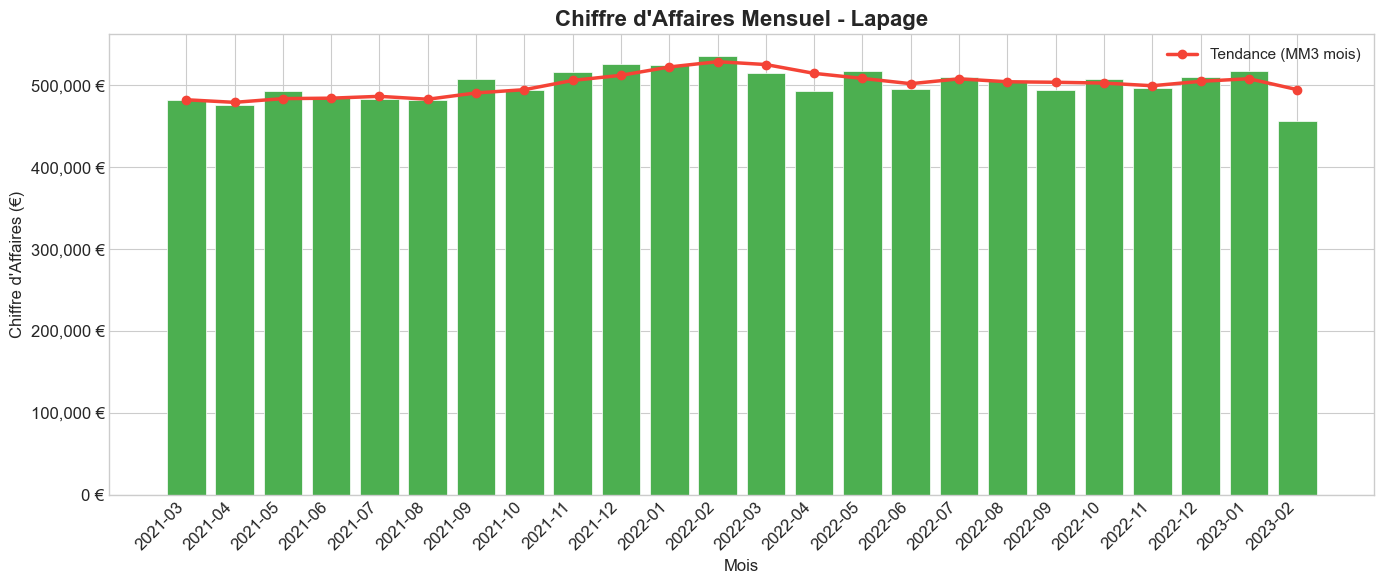

In [15]:
# Graphique CA mensuel avec barres
fig, ax = plt.subplots(figsize=(14, 6))

# Créer les labels pour les mois
ca_mensuel['mois_label'] = ca_mensuel['mois'].dt.strftime('%Y-%m')

# Barres
bars = ax.bar(
    ca_mensuel['mois_label'], 
    ca_mensuel['ca'],
    color='#4CAF50',
    edgecolor='white',
    linewidth=0.5
)

# Ligne de tendance (moyenne mobile sur les barres)
ax.plot(
    ca_mensuel['mois_label'], 
    ca_mensuel['ca'].rolling(window=3, min_periods=1).mean(),
    color='#F44336',
    linewidth=2.5,
    marker='o',
    markersize=6,
    label='Tendance (MM3 mois)'
)

# Mise en forme
ax.set_title('Chiffre d\'Affaires Mensuel - Lapage', fontsize=16, fontweight='bold')
ax.set_xlabel('Mois', fontsize=12)
ax.set_ylabel('Chiffre d\'Affaires (€)', fontsize=12)
ax.legend(loc='upper right', fontsize=11)

# Formater l'axe Y
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f} €'))

# Rotation des labels
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### 4.6 Tableau récapitulatif des KPIs

In [17]:
# Calcul des KPIs principaux
print("="*60)
print("📊 INDICATEURS CLÉS - CHIFFRE D'AFFAIRES")
print("="*60)

ca_total = transactions_enrichies['price'].sum()
ca_moyen_jour = ca_journalier['ca'].mean()
ca_moyen_semaine = ca_hebdo['ca'].mean()
ca_moyen_mois = ca_mensuel['ca'].mean()

print(f"\n💰 CA Total            : {ca_total:>15,.2f} €")
print(f"📅 CA Moyen / Jour     : {ca_moyen_jour:>15,.2f} €")
print(f"📅 CA Moyen / Semaine  : {ca_moyen_semaine:>15,.2f} €")
print(f"📅 CA Moyen / Mois     : {ca_moyen_mois:>15,.2f} €")

print(f"\n📈 Meilleur mois       : {ca_mensuel.loc[ca_mensuel['ca'].idxmax(), 'mois_label']} ({ca_mensuel['ca'].max():,.2f} €)")
print(f"📉 Moins bon mois      : {ca_mensuel.loc[ca_mensuel['ca'].idxmin(), 'mois_label']} ({ca_mensuel['ca'].min():,.2f} €)")

print("\n" + "="*60)

📊 INDICATEURS CLÉS - CHIFFRE D'AFFAIRES

💰 CA Total            :   12,027,663.10 €
📅 CA Moyen / Jour     :       16,476.25 €
📅 CA Moyen / Semaine  :      114,549.17 €
📅 CA Moyen / Mois     :      501,152.63 €

📈 Meilleur mois       : 2022-02 (535,571.50 €)
📉 Moins bon mois      : 2023-02 (456,679.76 €)



---

## 📝 Récapitulatif

### Ce que nous avons appris :

| Compétence | Méthodes utilisées |
|------------|-------------------|
| Convertir des dates | `pd.to_datetime()` |
| Agréger par période | `pd.Grouper(key, freq)` avec 'D', 'W', 'M' |
| Calculer une moyenne mobile | `.rolling(window=n).mean()` |
| Visualiser des séries temporelles | `plt.plot()`, `plt.bar()` |

### Prochaines étapes (Jour 3+) :
- Compléter les analyses pour Annabelle (courbe de Lorenz, Top/Flop)
- Réaliser les 5 corrélations pour Julie
- Préparer la présentation CODIR